# Case Study: Neural Network Pruning via Graph Centrality
## 1. Algorithmic Formulation and Complexity Goals

In this study, we reframe neural network pruning as a graph reduction problem. A fully connected layer is modeled as a directed bipartite graph $G = (V, E)$. 
* $V = V_{in} \cup V_{out}$ (Input and output neurons)
* $E = \{w_{ij} \mid \text{connection exists between } i \text{ and } j\}$

**DAA Objective:**
1. Construct the adjacency structure in $O(|V_{in}| \times |V_{out}|)$ time.
2. Compute Graph Centrality to evaluate node importance.
3. Execute a pruning algorithm to eliminate vertices with the lowest structural significance, reducing the spatial complexity from $O(|V_{in}| \times |V_{out}|)$ to a strictly bounded sparse subset.

In [1]:
# [IMPORT_LIBRARIES]
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import networkx as nx
import matplotlib.pyplot as plt
import numpy as np

# [DATASET_LOADER]
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,))
])

# [INIT_DATALOADERS]
train_loader = DataLoader(
    datasets.MNIST(root='./data', train=True, download=True, transform=transform), 
    batch_size=64, 
    shuffle=True
)
test_loader = DataLoader(
    datasets.MNIST(root='./data', train=False, transform=transform), 
    batch_size=1000, 
    shuffle=False
)

100%|██████████| 9.91M/9.91M [00:01<00:00, 5.95MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 157kB/s]
100%|██████████| 1.65M/1.65M [00:01<00:00, 1.49MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 8.06MB/s]


In [2]:
# [DEFINE_MODEL]
class BipartiteCNN(nn.Module):
    def __init__(self):
        super(BipartiteCNN, self).__init__()
        self.conv = nn.Conv2d(1, 16, kernel_size=3, padding=1)
        self.fc1 = nn.Linear(16 * 14 * 14, 128)
        self.fc2 = nn.Linear(128, 10)
        
        # [INIT_PRUNING_MASK]
        self.mask = torch.ones(128)

    def forward(self, x):
        x = torch.max_pool2d(torch.relu(self.conv(x)), 2)
        x = x.view(-1, 16 * 14 * 14)
        x = self.fc1(x)
        
        # [APPLY_MASK_O(V)]
        if self.mask.device != x.device:
            self.mask = self.mask.to(x.device)
        x = x * self.mask
        
        x = torch.relu(x)
        return self.fc2(x)

In [3]:
# [DEFINE_TRAINING_ALGORITHM]
def train_model(model, optimizer, criterion, epochs=1):
    model.train()
    for epoch in range(epochs):
        for data, target in train_loader:
            optimizer.zero_grad()
            output = model(data)
            loss = criterion(output, target)
            loss.backward()
            optimizer.step()

# [DEFINE_EVALUATION_ALGORITHM]
def test_model(model):
    model.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for data, target in test_loader:
            output = model(data)
            pred = output.argmax(dim=1, keepdim=True)
            correct += pred.eq(target.view_as(pred)).sum().item()
            total += target.size(0)
    return correct / total

In [4]:
# [EXECUTE_BASELINE]
baseline_model = BipartiteCNN()
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(baseline_model.parameters(), lr=0.001)

print("Executing Baseline CNN Training...")
train_model(baseline_model, optimizer, criterion, epochs=2)
baseline_accuracy = test_model(baseline_model)

# [CALC_BASELINE_COMPLEXITY]
baseline_params = sum(p.numel() for p in baseline_model.parameters())

print(f"Baseline Accuracy: {baseline_accuracy * 100:.2f}%")
print(f"Baseline Spatial Complexity (Params): {baseline_params}")

Executing Baseline CNN Training...
Baseline Accuracy: 97.79%
Baseline Spatial Complexity (Params): 402986


In [5]:
# [DEFINE_COMPLEXITY_SUMMARY_ALGORITHM]
def print_spatial_complexity(model):
    total_params = 0
    print("Layer\t\t\tShape\t\t\tParameters")
    for name, parameter in model.named_parameters():
        if not parameter.requires_grad:
            continue
        params = parameter.numel()
        shape = list(parameter.shape)
        print(f"{name:20}\t{str(shape):20}\t{params}")
        total_params += params
    print(f"Total Spatial Complexity: {total_params} parameters\n")

# [EXECUTE_SUMMARY]
print_spatial_complexity(baseline_model)

Layer			Shape			Parameters
conv.weight         	[16, 1, 3, 3]       	144
conv.bias           	[16]                	16
fc1.weight          	[128, 3136]         	401408
fc1.bias            	[128]               	128
fc2.weight          	[10, 128]           	1280
fc2.bias            	[10]                	10
Total Spatial Complexity: 402986 parameters



## 2. Graph Algorithms: Conversion and Centrality

We extract the dense weight matrix $W$ and construct a sparse adjacency list by applying a threshold $\tau$. 
To evaluate node importance, we compute **Degree Centrality**: $C_D(v) = \deg(v)$. 
While Betweenness Centrality offers deeper structural insights via Brandes' Algorithm $O(|V||E|)$, Degree Centrality bounds our time complexity to $O(|E|)$, which is optimal for highly dense matrices. We then sort the nodes in $O(|V| \log |V|)$ time.

In [6]:
# [EXTRACT_WEIGHTS]
weights = baseline_model.fc1.weight.data.abs().cpu().numpy()
num_out, num_in = weights.shape

# [DYNAMIC_THRESHOLD_O(V*E)]
# Automatically calculates the threshold to keep the top 5% strongest edges
threshold = np.percentile(weights, 95)

# [VECTORIZED_EDGE_EXTRACTION_O(V*E)]
# Bypasses slow Python loops using C-backend numpy operations
valid_rows, valid_cols = np.where(weights > threshold)
valid_rows_offset = valid_rows + num_in 
edge_weights = weights[valid_rows, valid_cols]

# [CONSTRUCT_GRAPH]
G = nx.Graph()
G.add_nodes_from(range(num_in), bipartite=0)
G.add_nodes_from(range(num_in, num_in + num_out), bipartite=1)

edges = list(zip(valid_cols, valid_rows_offset, edge_weights))
G.add_weighted_edges_from(edges)

# [COMPUTE_CENTRALITY_O(E)]
print(f"Graph constructed with {G.number_of_edges()} dynamic edges.")
print("Computing Degree Centrality...")
centrality = nx.degree_centrality(G)
out_node_scores = {n: centrality[n] for n in range(num_in, num_in + num_out)}

# [SORT_AND_SELECT_O(V_log_V)]
pruning_ratio = 0.5
num_prune = int(num_out * pruning_ratio)
sorted_nodes = sorted(out_node_scores.items(), key=lambda x: x[1])
nodes_to_prune = [n[0] - num_in for n in sorted_nodes[:num_prune]]
nodes_to_keep = [n[0] - num_in for n in sorted_nodes[num_prune:]]

Graph constructed with 20071 dynamic edges.
Computing Degree Centrality...


## 2.1 Heuristic Variance Analysis (Centrality Distribution)

For a greedy algorithm to effectively optimize a graph, there must be a measurable variance in the heuristic metric. We plot the statistical distribution of the Degree Centrality scores $C_D(v)$ across all vertices in $V_{out}$. A non-uniform distribution confirms that certain neurons act as topological hubs, while others are structurally redundant and safe for algorithmic removal.

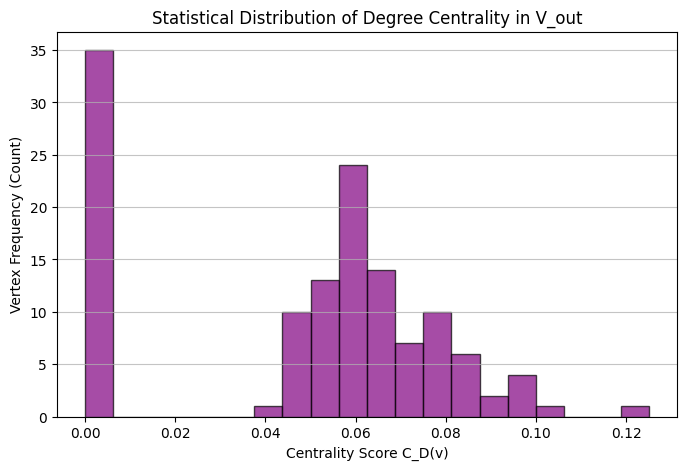

Centrality Statistics:
Mean Centrality:   0.0481
Median Centrality: 0.0570
Standard Dev:      0.0322


In [7]:
# [EXTRACT_SCORES_ARRAY]
scores_array = np.array(list(out_node_scores.values()))

# [PLOT_CENTRALITY_HISTOGRAM]
plt.figure(figsize=(8, 5))
plt.hist(scores_array, bins=20, color='purple', alpha=0.7, edgecolor='black')
plt.title("Statistical Distribution of Degree Centrality in V_out")
plt.xlabel("Centrality Score C_D(v)")
plt.ylabel("Vertex Frequency (Count)")
plt.grid(axis='y', alpha=0.75)
plt.show()

# [CALC_CENTRALITY_STATISTICS]
print("Centrality Statistics:")
print(f"Mean Centrality:   {np.mean(scores_array):.4f}")
print(f"Median Centrality: {np.median(scores_array):.4f}")
print(f"Standard Dev:      {np.std(scores_array):.4f}")

Edges present for visualization: 22


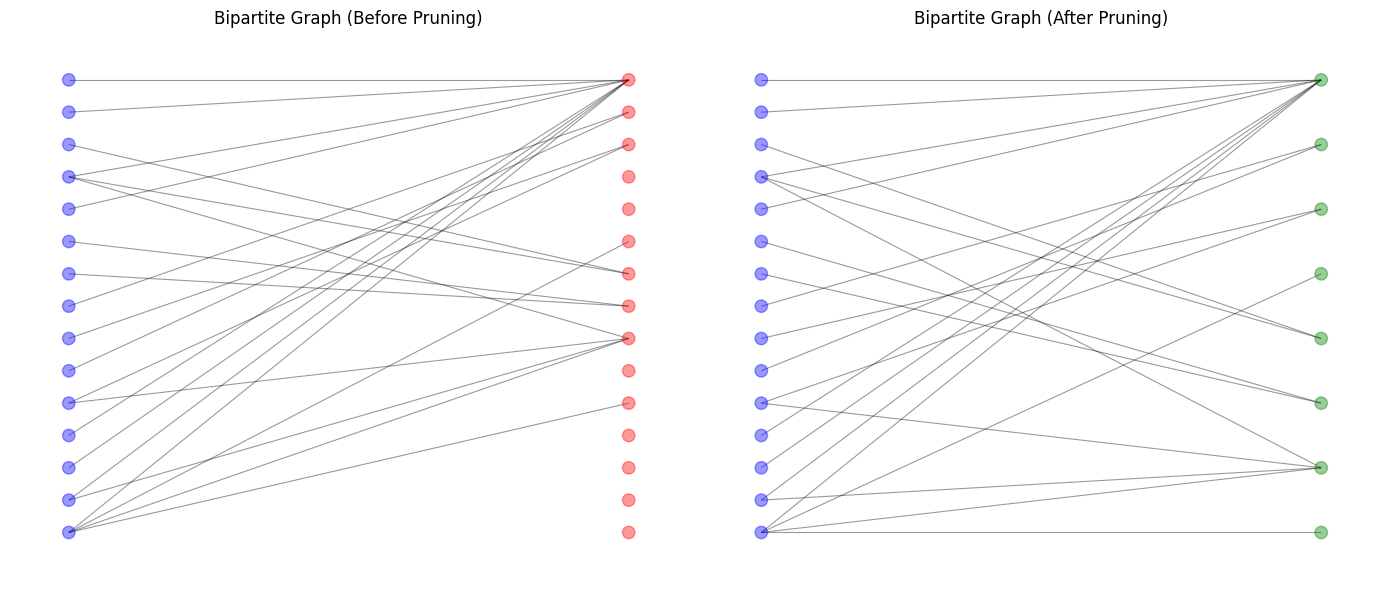

In [8]:
# [ROBUST_NODE_SELECTION]
sample_out_keep = [n + num_in for n in nodes_to_keep if (n + num_in) in G.nodes()][:8]
sample_out_prune = [n + num_in for n in nodes_to_prune if (n + num_in) in G.nodes()][:7]
sample_out = sample_out_keep + sample_out_prune

# [GUARANTEE_EDGES]
connected_inputs = set()
for node in sample_out:
    connected_inputs.update(G.neighbors(node))

sample_in = list(connected_inputs)[:15]
subgraph_before = G.subgraph(sample_in + sample_out)

# [VERIFY_EDGES]
print(f"Edges present for visualization: {subgraph_before.number_of_edges()}")

# [PLOT_BEFORE_PRUNING]
plt.figure(figsize=(14, 6))
plt.subplot(1, 2, 1)

pos_before = nx.bipartite_layout(subgraph_before, nodes=sample_in)
color_map_before = ['blue' if n < num_in else 'red' for n in subgraph_before.nodes()]

nx.draw(subgraph_before, pos_before, node_color=color_map_before, node_size=80, edge_color='black', width=0.8, alpha=0.4)
plt.title("Bipartite Graph (Before Pruning)")

# [EXECUTE_PRUNING_ON_SUBGRAPH]
G_after = G.copy()
G_after.remove_nodes_from([n + num_in for n in nodes_to_prune])
subgraph_after = G_after.subgraph(sample_in + sample_out)

# [PLOT_AFTER_PRUNING]
plt.subplot(1, 2, 2)
pos_after = nx.bipartite_layout(subgraph_after, nodes=sample_in)
color_map_after = ['blue' if n < num_in else 'green' for n in subgraph_after.nodes()]

nx.draw(subgraph_after, pos_after, node_color=color_map_after, node_size=80, edge_color='black', width=0.8, alpha=0.4)
plt.title("Bipartite Graph (After Pruning)")

plt.tight_layout()
plt.show()

## 3. Empirical Results: Spatial Complexity and Accuracy Trade-off

By mathematically zeroing out the lowest centrality nodes, we bypass the need to compute their gradient paths. Here we evaluate the pruned model, execute a fine-tuning pass, and compare the asymptotic reductions in parameter space against the baseline model.

In [9]:
# [APPLY_PRUNING_MASK]
pruned_model = BipartiteCNN()
pruned_model.load_state_dict(baseline_model.state_dict())

with torch.no_grad():
    for node in nodes_to_prune:
        pruned_model.mask[node] = 0.0

print("Evaluating Pre-Finetune Pruned Model...")
acc_immediate_drop = test_model(pruned_model)

# [FINETUNE_PRUNED_MODEL]
print("Fine-tuning Pruned Model...")
optimizer_pruned = optim.Adam(pruned_model.parameters(), lr=0.0005)
train_model(pruned_model, optimizer_pruned, criterion, epochs=1)
pruned_accuracy_final = test_model(pruned_model)

# [CALC_PRUNED_COMPLEXITY]
edges_removed = num_prune * num_in
biases_removed = num_prune
pruned_params = baseline_params - edges_removed - biases_removed
param_reduction = ((baseline_params - pruned_params) / baseline_params) * 100

# [OUTPUT_FINAL_COMPARISON]
print("\n" + "="*40)
print("ALGORITHM PERFORMANCE COMPARISON")
print("="*40)
print(f"Baseline Accuracy:           {baseline_accuracy * 100:.2f}%")
print(f"Accuracy (Immediate Prune):  {acc_immediate_drop * 100:.2f}%")
print(f"Accuracy (Post Fine-Tuning): {pruned_accuracy_final * 100:.2f}%\n")

print(f"Original Spatial Complexity: {baseline_params} parameters")
print(f"Pruned Spatial Complexity:   {pruned_params} parameters")
print(f"Total Parameter Reduction:   {param_reduction:.2f}%")
print("="*40)

Evaluating Pre-Finetune Pruned Model...
Fine-tuning Pruned Model...

ALGORITHM PERFORMANCE COMPARISON
Baseline Accuracy:           97.79%
Accuracy (Immediate Prune):  94.20%
Accuracy (Post Fine-Tuning): 98.25%

Original Spatial Complexity: 402986 parameters
Pruned Spatial Complexity:   202218 parameters
Total Parameter Reduction:   49.82%


## 4. Final Algorithmic Performance Visualization

We visualize the trade-off between spatial complexity reduction and predictive accuracy. An optimal graph pruning algorithm will show a steep drop in the parameter metric with a negligible (or positive) change in the accuracy metric.

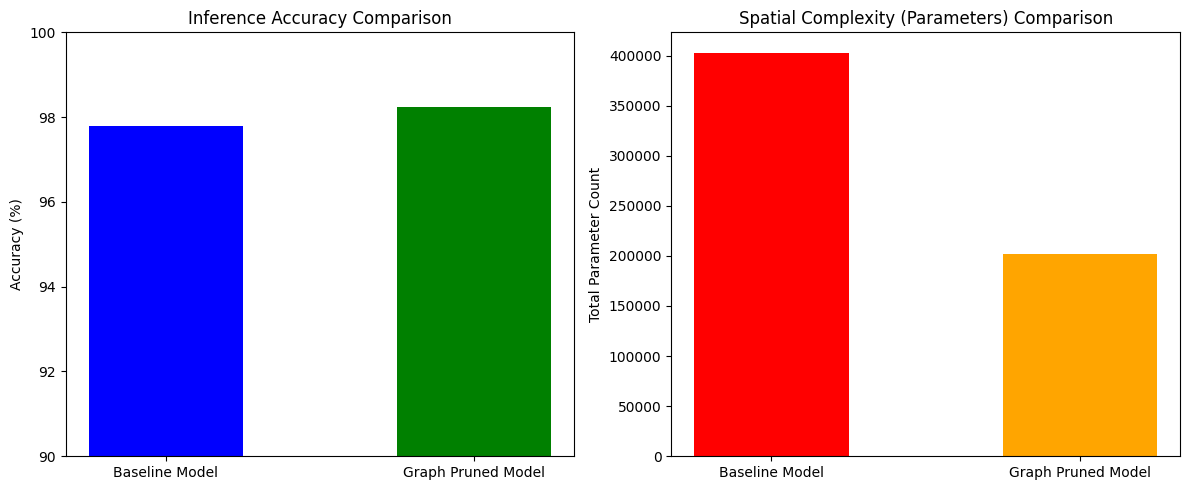

In [10]:
# [PREPARE_STATISTICAL_DATA]
metrics = ['Baseline Model', 'Graph Pruned Model']
accuracies = [baseline_accuracy * 100, pruned_accuracy_final * 100]
parameters = [baseline_params, pruned_params]

# [PLOT_COMPARATIVE_BAR_CHARTS]
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

ax1.bar(metrics, accuracies, color=['blue', 'green'], width=0.5)
ax1.set_title("Inference Accuracy Comparison")
ax1.set_ylabel("Accuracy (%)")
ax1.set_ylim(90, 100) 

ax2.bar(metrics, parameters, color=['red', 'orange'], width=0.5)
ax2.set_title("Spatial Complexity (Parameters) Comparison")
ax2.set_ylabel("Total Parameter Count")

plt.tight_layout()
plt.show()